In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(os.getcwd())
os.chdir("../../soge-home/projects/mistral/mans4178/schools")
print(os.getcwd())

/hn01-home/mans4178
/lustre/soge1/projects/mistral/mans4178/schools


In [3]:
ISO3 = "ETH"

### Prepare survey data

Household survey source:
https://microdata.worldbank.org/index.php/catalog/6161/

In [4]:
survey = pd.read_csv("validation/survey_data/ETH/ETH_2021_ESPS-W5_v01_M_CSV/sect2_hh_w5.csv")

In [5]:
print("Number of survey responses: "+str(len(survey)))
print("Number of non-empty responses: "+str(survey.s2q14.count()))

Number of survey responses: 22688
Number of non-empty responses: 6978


In [6]:
# Filter empty responses
survey = survey[survey["s2q14"].notnull()]

In [7]:
def survey_match(x):
    if x == "1. 0 - 15":
        return 1
    elif x == "2. 16 - 30":
        return 16
    elif x == "3. 31 - 45":
        return 31
    elif x == "4. 46 - 60": 
        return 46
    elif x == "5. 61 - 90":
        return 61
    elif x == "6. 91 - 120":
        return 91
    elif x == "7. 120 +":
        return 121

In [8]:
# Convert format
survey["traveltime"] = survey.apply(lambda x: survey_match(x["s2q14"]), axis=1)

In [9]:
# Filter not tertiary
survey["s2q09b"] = survey["s2q09"].str.split('.').str[0].astype(int)
survey = survey[(survey['s2q09b'] > 0) & (survey['s2q09b'] <=12)]

In [10]:
print("Number of non-empty, primary and secondary schools only responses: "+str(survey.traveltime.count()))

Number of non-empty, primary and secondary schools only responses: 5168


In [11]:
# Filter only walking 
survey = survey[survey["s2q13"]=="1. FOOT"]

# Filter only not-walking 
#survey = survey[survey["s2q13"]!="1. FOOT"]

In [12]:
print("Number of non-empty, primary and secondary schools, walking only responses: "+str(survey.traveltime.count()))

Number of non-empty, primary and secondary schools, walking only responses: 4755


In [13]:
tt_col = "traveltime"
weight_col = "pw_w5"

### Import model data

In [14]:
df_summary_1km = pd.read_csv(
    f"model_1km/outputs/jrc/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

df_summary_90m = pd.read_csv(
    f"model_90m/outputs/jrcwalking/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

### Plot distributions

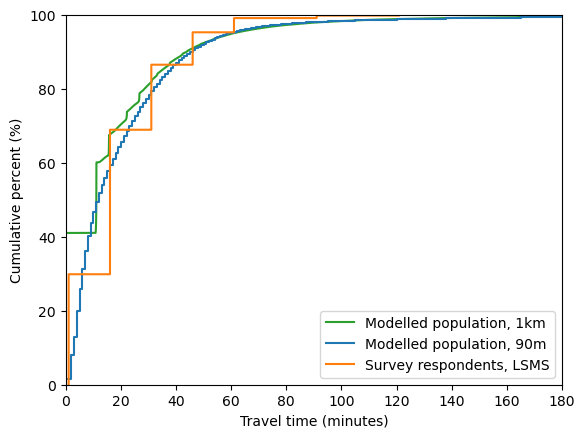

In [15]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df_summary_1km, x="traveltime", weights="pop", stat="percent", label="Modelled population, 1km", color=sns.color_palette()[2])
sns.ecdfplot(data=df_summary_90m, x="traveltime", weights="pop", stat="percent", label="Modelled population, 90m", color=sns.color_palette()[0])
sns.ecdfplot(data=survey, x=tt_col, weights=weight_col, stat="percent", label="Survey respondents, LSMS", color=sns.color_palette()[1])
ax.set_xlim([0, 180])
ax.set_ylim([0, 100])
ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Cumulative percent (%)")
ax.legend(loc ='lower right')
plt.show()

### Compare CDFs (areas between curves)

In [16]:
import validation.ipynb.compare_cdfs as compare_cdfs

In [17]:
metrics_90m = compare_cdfs.compare_cdfs(df_summary_90m,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [18]:
metrics_1km = compare_cdfs.compare_cdfs(df_summary_1km,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [20]:
table = pd.DataFrame([metrics_90m, metrics_1km], index=["90m model", "1km model"])
table = table.reset_index().rename(columns={"index": "model"})
table.insert(0, "ISO3", ISO3)
table.to_csv(f"validation/model_comp/cdf_metrics__{ISO3}.csv")
table

,ISO3,model,A+,A-,Aabs,A+_norm,A-_norm,Aabs_norm
0,ETH,90m model,0.008278,5.533946,5.542224,0.000069,0.046116,0.046185
1,ETH,1km model,0.519596,3.397457,3.917054,0.004330,0.028312,0.032642
